In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load the raw cryptocurrency dataset
# This step performs data acquisition only; no transformations are applied
raw_df = pd.read_csv("crypto_historical_365days.csv")

# Preview raw data
raw_df.head()

,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,241.886714,241.886714,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,5.820864,248.926662,248.926662,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-2.882097,248.814243,248.814243,6.153922,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,13.341583,257.049474,257.049474,8.119016,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.228372,262.119303,262.119303,7.120498,16.748297,2024-12


In [5]:
# Inspect schema, data types, and non-null counts
raw_df.info()

# Generate descriptive statistics for numeric and categorical fields
raw_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33364 entries, 0 to 33363
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   coin_id            33364 non-null  object 
 1   coin_name          33364 non-null  object 
 2   symbol             33364 non-null  object 
 3   market_cap_rank    33364 non-null  int64  
 4   timestamp          33364 non-null  object 
 5   date               33364 non-null  object 
 6   price              33364 non-null  float64
 7   market_cap         33364 non-null  float64
 8   volume             33364 non-null  float64
 9   daily_return       33264 non-null  float64
 10  price_ma7          33364 non-null  float64
 11  price_ma30         33364 non-null  float64
 12  volatility_7d      33164 non-null  float64
 13  cumulative_return  33264 non-null  float64
 14  month              33364 non-null  object 
dtypes: float64(8), int64(1), object(6)
memory usage: 3.8+ MB


,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
count,33364,33364,33364,33364.000000,33364,33364,33364.000000,3.336400e+04,3.336400e+04,33264.000000,33364.000000,33364.000000,33164.000000,33264.000000,33364
unique,100,100,97,NaN,465,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13
top,aave,Aave,SOL,NaN,2025-11-24 00:00:00,2025-12-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-10
freq,366,366,732,NaN,100,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3057
mean,NaN,NaN,NaN,49.647554,NaN,NaN,4935.370689,3.740995e+10,2.267570e+09,0.006311,4938.045186,4950.016427,3.341479,-0.954928,NaN
std,NaN,NaN,NaN,29.297393,NaN,NaN,21026.134092,2.170265e+11,1.165108e+10,4.968284,21030.766879,21062.153924,3.769143,198.786656,NaN
min,NaN,NaN,NaN,1.000000,NaN,NaN,0.000002,0.000000e+00,0.000000e+00,-76.575558,0.000002,0.000002,0.000000,-87.110714,NaN
25%,NaN,NaN,NaN,24.000000,NaN,NaN,0.999408,1.484588e+09,2.355836e+07,-1.614341,0.999587,0.999680,1.157136,-44.110582,NaN
50%,NaN,NaN,NaN,49.000000,NaN,NaN,3.373112,3.059569e+09,1.239228e+08,0.000000,3.382747,3.548318,2.928408,-11.790919,NaN
75%,NaN,NaN,NaN,75.000000,NaN,NaN,190.019842,8.223864e+09,4.350004e+08,1.317147,191.887314,196.344415,4.582064,1.036534,NaN


In [6]:
# Define a function to clean and transform raw cryptocurrency data
# This function converts raw data into a processed form suitable for analysis
def clean_crypto_data(df):
    df = df.copy()
    
    # Convert date column to datetime format
    df['date'] = pd.to_datetime(df['date'])
    
    # Sort data to ensure correct time-series calculations
    df = df.sort_values(['coin_name', 'date'])
    
    # Calculate daily returns for each cryptocurrency
    df['daily_return'] = df.groupby('coin_name')['price'].pct_change()
    
    # Compute rolling moving averages
    df['price_ma7'] = (
        df.groupby('coin_name')['price']
        .rolling(window=7)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    df['price_ma30'] = (
        df.groupby('coin_name')['price']
        .rolling(window=30)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Compute rolling 7-day volatility based on daily returns
    df['volatility_7d'] = (
        df.groupby('coin_name')['daily_return']
        .rolling(window=7)
        .std()
        .reset_index(level=0, drop=True)
    )
    
    return df

In [7]:
# Apply cleaning and transformation to raw data
clean_df = clean_crypto_data(raw_df)

# Preview processed dataset
clean_df.head()

,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,NaN,NaN,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,0.058209,NaN,NaN,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-0.028821,NaN,NaN,NaN,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,0.133416,NaN,NaN,NaN,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.002284,NaN,NaN,NaN,16.748297,2024-12


In [8]:
# Save the cleaned dataset to preserve a reproducible processed version
clean_df.to_csv("crypto_clean_processed.csv", index=False)

In [9]:
# Generate summary statistics for key quantitative fields
summary_stats = clean_df[['price', 'volume', 'daily_return', 'volatility_7d']].describe()

summary_stats

,price,volume,daily_return,volatility_7d
count,33364.000000,3.336400e+04,33264.000000,32664.000000
mean,4935.370689,2.267570e+09,0.000063,0.033120
std,21026.134092,1.165108e+10,0.049683,0.036777
min,0.000002,0.000000e+00,-0.765756,0.000000
25%,0.999408,2.355836e+07,-0.016143,0.011601
50%,3.373112,1.239228e+08,0.000000,0.029199
75%,190.019842,4.350004e+08,0.013171,0.045610
max,125397.347055,2.794751e+11,3.461771,1.391829


In [10]:
# Compute correlation between daily returns and short-term volatility
# This serves as ground-truth validation for any narrative or LLM-assisted insights
correlations = clean_df[['daily_return', 'volatility_7d']].corr()

correlations

,daily_return,volatility_7d
daily_return,1.000000,0.130118
volatility_7d,0.130118,1.000000


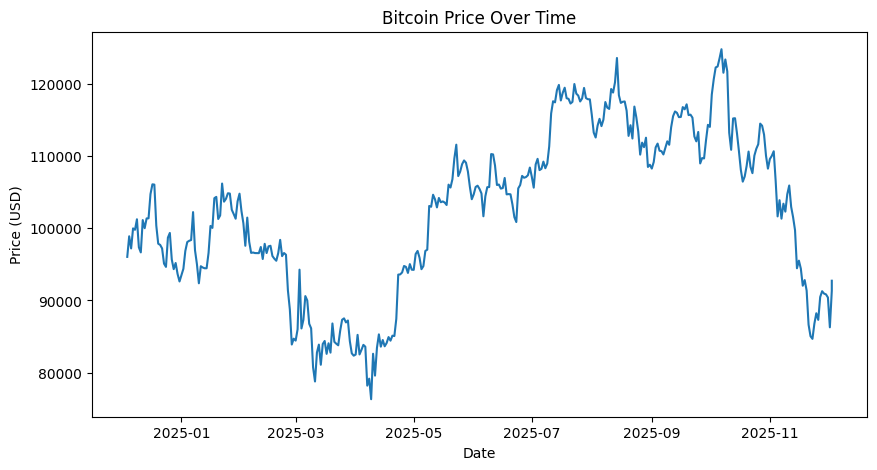

In [11]:
# Visualize price trends for a major cryptocurrency (Bitcoin)
btc_df = clean_df[clean_df['coin_name'] == 'Bitcoin']

plt.figure(figsize=(10, 5))
plt.plot(btc_df['date'], btc_df['price'])
plt.title("Bitcoin Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

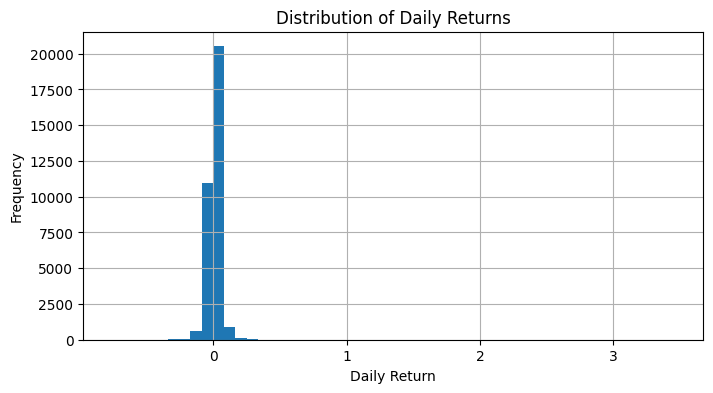

In [12]:
# Visualize distribution of daily returns across all cryptocurrencies
plt.figure(figsize=(8, 4))
clean_df['daily_return'].dropna().hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

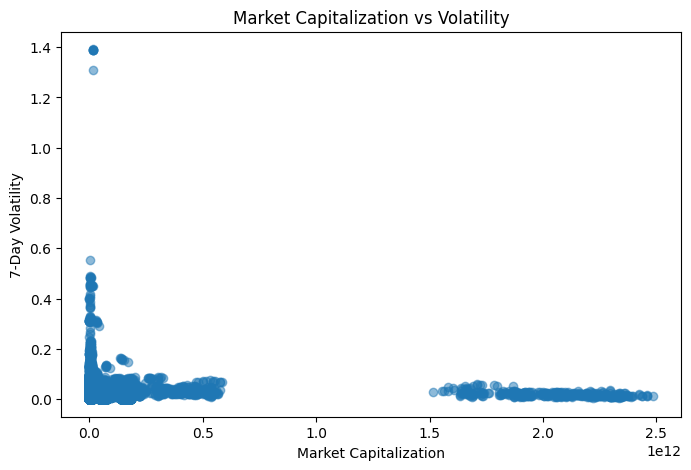

In [13]:
# Analyze relationship between market capitalization and volatility
plt.figure(figsize=(8, 5))
plt.scatter(clean_df['market_cap'], clean_df['volatility_7d'], alpha=0.5)
plt.xlabel("Market Capitalization")
plt.ylabel("7-Day Volatility")
plt.title("Market Capitalization vs Volatility")
plt.show()

In [14]:
# LLM USAGE DOCUMENTATION
# -----------------------
# A large language model was used only to assist with hypothesis generation
# and narrative framing based on the computed statistics and visual outputs.
# All metrics, calculations, and visualizations were produced programmatically.
# LLM-generated suggestions were treated strictly as hypotheses and were
# validated against ground-truth statistical outputs such as correlation analysis.
# No analytical results were directly generated by the LLM.

In [15]:
# Validate potential hypothesis that volatility follows strong return movements
# Empirical correlation analysis shows a weak relationship, indicating limited support
correlations

,daily_return,volatility_7d
daily_return,1.000000,0.130118
volatility_7d,0.130118,1.000000
